In [1]:
from dataclasses import dataclass
from collections import defaultdict
import math
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

OUT_DIR = Path("/mnt/data") if Path("/mnt/data").exists() else Path(".")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# For reproducible layouts and random graph generation
GLOBAL_SEED = 2
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [2]:
#  Input format: (u, v, original_length)
raw_edges = [
    (0, 1, 1),
    (0, 2, 1),
    (1, 2, 2),
    (1, 3, 3),
    (2, 3, 4),
]

root_vertex = 0

G_raw = nx.Graph()
G_raw.add_weighted_edges_from(raw_edges)

print("Raw graph edges:")
for u, v, w in raw_edges:
    print(f"  edge {u}-{v}, original length = {w}")

print("\nConnected:", nx.is_connected(G_raw))
print("Number of vertices |V|:", G_raw.number_of_nodes())
print("Number of edges |E|:", G_raw.number_of_edges())

Raw graph edges:
  edge 0-1, original length = 1
  edge 0-2, original length = 1
  edge 1-2, original length = 2
  edge 1-3, original length = 3
  edge 2-3, original length = 4

Connected: True
Number of vertices |V|: 4
Number of edges |E|: 5


In [3]:
#A delayed spike encodes an edge length. If two candidate edges have the same delay, two post-synaptic graph neurons may spike at the same time, so the selected edge is ambiguous.

#As per paper: multiply each original length by the maximum duplicate count and then add a distinct offset among edges with the same original length.


def make_unique_integer_lengths(edge_list):

    grouped = defaultdict(list)

    for u, v, w in edge_list:
        if w <= 0 or int(w) != w:
            raise ValueError("This notebook expects positive integer edge lengths.")
        grouped[int(w)].append((u, v, int(w)))

    max_dup = max(len(items) for items in grouped.values()) if grouped else 1

    unique_edges = []
    rows = []

    for original_w in sorted(grouped):
        for offset, (u, v, w) in enumerate(sorted(grouped[original_w])):
            unique_delay = original_w * max_dup + offset
            unique_edges.append((u, v, unique_delay))
            rows.append({
                "u": u,
                "v": v,
                "original_length": original_w,
                "offset": offset,
                "unique_delay": unique_delay,
            })

    return unique_edges, pd.DataFrame(rows)

unique_edges, unique_mapping = make_unique_integer_lengths(raw_edges)

print("Unique-delay graph edges:")
for u, v, d in unique_edges:
    print(f"  edge {u}-{v}, synaptic delay = {d}")

display(unique_mapping)

Unique-delay graph edges:
  edge 0-1, synaptic delay = 2
  edge 0-2, synaptic delay = 3
  edge 1-2, synaptic delay = 4
  edge 1-3, synaptic delay = 6
  edge 2-3, synaptic delay = 8


,u,v,original_length,offset,unique_delay
0,0,1,1,0,2
1,0,2,1,1,3
2,1,2,2,0,4
3,1,3,3,0,6
4,2,3,4,0,8


In [4]:
#defining neuron alnd all

@dataclass(frozen=True)
class NeuronSpec:
    name: str
    threshold: float
    reset: float
    leak: float
    role: str = "regular"

@dataclass(frozen=True)
class SynapseSpec:
    pre: str
    post: str
    delay: int
    weight: float
    label: str = ""

In [5]:
# A low level simulator with our simsnn ( authors used their simulator , you can find in gitlab , its good though

def build_low_level_mst_snn(unique_edges, root=0):

    vertices = sorted({u for u, _, _ in unique_edges} | {v for _, v, _ in unique_edges})
    n = len(vertices)

    if root not in vertices:
        raise ValueError("root must be one of the graph vertices")

    neurons = {}
    synapses = []

    def add_neuron(name, T, R, m, role):
        neurons[name] = NeuronSpec(name=name, threshold=float(T), reset=float(R), leak=float(m), role=role)

    def add_synapse(pre, post, delay, weight, label=""):
        if delay < 1:
            raise ValueError("Synaptic delays must be positive integers.")
        synapses.append(SynapseSpec(pre=pre, post=post, delay=int(delay), weight=float(weight), label=label))

    # Global control neuron
    add_neuron("Programmed", math.inf, 0, 0, "programmed")
    add_neuron("Start", 1, 0, 0, "global")
    add_neuron("Inhibit", n, 0, 1, "global")
    add_neuron("Reset", 1, 0, 0, "global")
    add_neuron("Accept", n - 1, 0, 1, "global")

    # Per-vertex neuron
    for v in vertices:
        add_neuron(f"vgraph[{v}]", n, 0, 1, "vgraph")
        add_neuron(f"vpart[{v}]", n + 1, n, 1, "vpart")
        add_neuron(f"vadd[{v}]", 2, 0, 1, "vadd")

    # First external program spike
    add_synapse("Programmed", "Start", 1, 1, "external start")

    #  initialize
    for v in vertices:
        add_synapse("Start", f"vgraph[{v}]", 1, n - 1, "precharge vgraph")
        add_synapse("Start", f"vadd[{v}]", 1, 1, "precharge vadd")
        add_synapse("Start", f"vpart[{v}]", 1, 1, "query vpart membership")
    add_synapse("Start", "Inhibit", 1, n - 1, "precharge inhibit")


    # Delay-2 inhibitory paths cancel their vgraph output at vadd/Inhibit so it prevents old MST vertices from being re-added.
    for v in vertices:
        add_synapse(f"vpart[{v}]", f"vgraph[{v}]", 1, 1, "activate stored MST vertex")
        add_synapse(f"vpart[{v}]", f"vadd[{v}]", 2, -1, "cancel old vertex at vadd")
        add_synapse(f"vpart[{v}]", "Inhibit", 2, -1, "cancel old vertex at inhibit")

    # Graph embedding
    for u, v, delay in unique_edges:
        add_synapse(f"vgraph[{u}]", f"vgraph[{v}]", delay, 1, f"graph edge {u}->{v}")
        add_synapse(f"vgraph[{v}]", f"vgraph[{u}]", delay, 1, f"graph edge {v}->{u}")

    # A newly reached graph neuron creats vertex
    for v in vertices:
        add_synapse(f"vgraph[{v}]", f"vadd[{v}]", 1, 1, "candidate reaches vadd")
        add_synapse(f"vgraph[{v}]", "Inhibit", 1, 1, "candidate triggers inhibit")
        add_synapse(f"vadd[{v}]", f"vpart[{v}]", 1, n + 1, "store accepted vertex")

    # stopping acceptance
    for v in vertices:
        add_synapse("Inhibit", f"vgraph[{v}]", 1, -n, "clear vgraph after acceptance")
        add_synapse("Inhibit", f"vadd[{v}]", 1, -2, "clear vadd after acceptance")
    add_synapse("Inhibit", "Accept", 1, 1, "count accepted edge")

    max_unique_delay = max(delay for _, _, delay in unique_edges)
    reset_delay = max(4, max_unique_delay + 1)
    add_synapse("Inhibit", "Reset", reset_delay, 1, "delayed reset after edge spikes pass")

    # Reset before iteration.
    for v in vertices:
        add_synapse("Reset", f"vgraph[{v}]", 1, -n, "reset vgraph")
        add_synapse("Reset", f"vadd[{v}]", 1, -2, "reset vadd")
    add_synapse("Reset", "Inhibit", 1, -n, "reset inhibit")
    add_synapse("Reset", "Start", 1, 1, "start next iteration")

    # Initial membrane potentials.
    initial_u = {name: 0.0 for name in neurons}
    initial_u[f"vpart[{root}]"] = float(n)  # root starts as part of the MST

    scheduled_spikes = {"Programmed": {1}}

    metadata = {
        "vertices": vertices,
        "n": n,
        "root": root,
        "max_unique_delay": max_unique_delay,
        "reset_delay": reset_delay,
    }

    return neurons, synapses, initial_u, scheduled_spikes, metadata

neurons, synapses, initial_u, scheduled_spikes, metadata = build_low_level_mst_snn(unique_edges, root_vertex)

print(json.dumps(metadata, indent=2))
print("Number of neurons:", len(neurons))
print("Number of synapses:", len(synapses))

{
  "vertices": [
    0,
    1,
    2,
    3
  ],
  "n": 4,
  "root": 0,
  "max_unique_delay": 8,
  "reset_delay": 9
}
Number of neurons: 17
Number of synapses: 68


In [6]:
# check MST, via spikes
neuron_table = pd.DataFrame([
    {
        "name": spec.name,
        "role": spec.role,
        "threshold T": spec.threshold,
        "reset R": spec.reset,
        "leak m": spec.leak,
        "initial u(0)": initial_u[spec.name],
    }
    for spec in neurons.values()
])

synapse_table = pd.DataFrame([
    {
        "pre": s.pre,
        "post": s.post,
        "delay d": s.delay,
        "weight w": s.weight,
        "label": s.label,
    }
    for s in synapses
])

display(neuron_table)
display(synapse_table.head(80))

,name,role,threshold T,reset R,leak m,initial u(0)
0,Programmed,programmed,inf,0.0,0.0,0.0
1,Start,global,1.0,0.0,0.0,0.0
2,Inhibit,global,4.0,0.0,1.0,0.0
3,Reset,global,1.0,0.0,0.0,0.0
4,Accept,global,3.0,0.0,1.0,0.0
5,vgraph[0],vgraph,4.0,0.0,1.0,0.0
6,vpart[0],vpart,5.0,4.0,1.0,4.0
7,vadd[0],vadd,2.0,0.0,1.0,0.0
8,vgraph[1],vgraph,4.0,0.0,1.0,0.0
9,vpart[1],vpart,5.0,4.0,1.0,0.0


,pre,post,delay d,weight w,label
0,Programmed,Start,1,1.0,external start
1,Start,vgraph[0],1,3.0,precharge vgraph
2,Start,vadd[0],1,1.0,precharge vadd
3,Start,vpart[0],1,1.0,query vpart membership
4,Start,vgraph[1],1,3.0,precharge vgraph
5,Start,vadd[1],1,1.0,precharge vadd
6,Start,vpart[1],1,1.0,query vpart membership
7,Start,vgraph[2],1,3.0,precharge vgraph
8,Start,vadd[2],1,1.0,precharge vadd
9,Start,vpart[2],1,1.0,query vpart membership


In [7]:
def simulate_snn(neurons, synapses, initial_u, scheduled_spikes, max_steps=1000, stop_on_accept=True):
    "small snn simulator"
    names = list(neurons.keys())

    incoming = defaultdict(list)
    for syn in synapses:
        incoming[syn.post].append(syn)

    u_hist = {0: dict(initial_u)}
    x_hist = {0: {name: 0 for name in names}}
    events = []
    stop_time = None

    for t in range(1, max_steps + 1):
        u_prev = u_hist[t - 1]
        u_t = {}
        x_t = {}

        for name, spec in neurons.items():
            if spec.role == "programmed":
                spike = int(t in scheduled_spikes.get(name, set()))
                u_t[name] = 0.0
                x_t[name] = spike
                if spike:
                    events.append({
                        "time": t,
                        "neuron": name,
                        "role": spec.role,
                        "u": np.nan,
                        "input_sum": np.nan,
                        "terms": "scheduled spike",
                    })
                continue

            input_sum = 0.0
            terms = []

            for syn in incoming[name]:
                source_time = t - syn.delay
                pre_spike = 0
                if source_time in x_hist:
                    pre_spike = x_hist[source_time].get(syn.pre, 0)

                if pre_spike:
                    contribution = syn.weight * pre_spike
                    input_sum += contribution
                    terms.append(f"{syn.pre}@{source_time} × {syn.weight:g}")

            if u_prev[name] >= spec.threshold:
                u_value = max(0.0, spec.reset + input_sum)
            else:
                u_value = max(0.0, spec.leak * u_prev[name] + input_sum)

            spike = int(u_value >= spec.threshold)
            u_t[name] = u_value
            x_t[name] = spike

            if spike:
                events.append({
                    "time": t,
                    "neuron": name,
                    "role": spec.role,
                    "u": u_value,
                    "input_sum": input_sum,
                    "terms": "; ".join(terms),
                })

        u_hist[t] = u_t
        x_hist[t] = x_t

        if stop_on_accept and x_t.get("Accept", 0) == 1:
            stop_time = t
            break

    if stop_time is None:
        stop_time = max_steps

    return {
        "u_hist": u_hist,
        "x_hist": x_hist,
        "events": pd.DataFrame(events),
        "stop_time": stop_time,
    }

In [8]:
result = simulate_snn(
    neurons=neurons,
    synapses=synapses,
    initial_u=initial_u,
    scheduled_spikes=scheduled_spikes,
    max_steps=1000,
    stop_on_accept=True,
)

print("Simulation finished at timestep:", result["stop_time"])
print("Total spikes until Accept:", len(result["events"]))
print("Accept spike observed:", bool((result["events"]["neuron"] == "Accept").any()))

display(result["events"])

Simulation finished at timestep: 43
Total spikes until Accept: 32
Accept spike observed: True


,time,neuron,role,u,input_sum,terms
0,1,Programmed,programmed,NaN,NaN,scheduled spike
1,2,Start,global,1.0,1.0,Programmed@1 × 1
2,3,vpart[0],vpart,5.0,1.0,Start@2 × 1
3,4,vgraph[0],vgraph,4.0,1.0,vpart[0]@3 × 1
4,6,vgraph[1],vgraph,4.0,1.0,vgraph[0]@4 × 1
5,7,Inhibit,global,4.0,1.0,vgraph[1]@6 × 1
6,7,vadd[1],vadd,2.0,1.0,vgraph[1]@6 × 1
7,7,vgraph[2],vgraph,4.0,1.0,vgraph[0]@4 × 1
8,8,vpart[1],vpart,6.0,5.0,vadd[1]@7 × 5
9,16,Reset,global,1.0,1.0,Inhibit@7 × 1


,Start,Inhibit,Reset,Accept,vpart[0],vgraph[0],vadd[1],vpart[1],vgraph[1],vadd[2],vpart[2],vgraph[2],vadd[3],vpart[3],vgraph[3]
0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,3.0,0.0,0.0,5.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0
4,0.0,3.0,0.0,0.0,4.0,4.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0
5,0.0,3.0,0.0,0.0,4.0,0.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0
6,0.0,3.0,0.0,0.0,4.0,0.0,1.0,1.0,4.0,1.0,1.0,3.0,1.0,1.0,3.0
7,0.0,4.0,0.0,0.0,4.0,0.0,2.0,1.0,0.0,1.0,1.0,4.0,1.0,1.0,3.0
8,0.0,1.0,0.0,1.0,4.0,0.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9,0.0,1.0,0.0,1.0,4.0,0.0,0.0,4.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


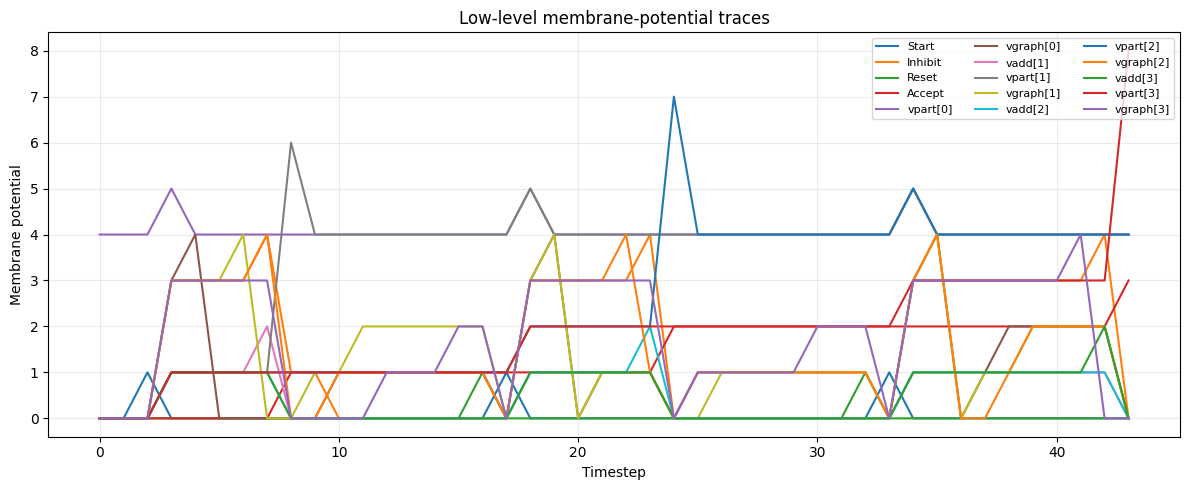

In [9]:
u_df = pd.DataFrame.from_dict(result["u_hist"], orient="index").sort_index()
x_df = pd.DataFrame.from_dict(result["x_hist"], orient="index").sort_index()

selected_neurons = [
    "Start", "Inhibit", "Reset", "Accept",
    "vpart[0]", "vgraph[0]",
    "vadd[1]", "vpart[1]", "vgraph[1]",
    "vadd[2]", "vpart[2]", "vgraph[2]",
    "vadd[3]", "vpart[3]", "vgraph[3]",
]
selected_neurons = [name for name in selected_neurons if name in u_df.columns]

display(u_df[selected_neurons].head(80))

plt.figure(figsize=(12, 5))
for name in selected_neurons:
    plt.plot(u_df.index, u_df[name], label=name)
plt.xlabel("Timestep")
plt.ylabel("Membrane potential")
plt.title("Low-level membrane-potential traces")
plt.legend(loc="upper right", ncol=3, fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_membrane_traces_new.png", dpi=300, bbox_inches="tight")
plt.show()

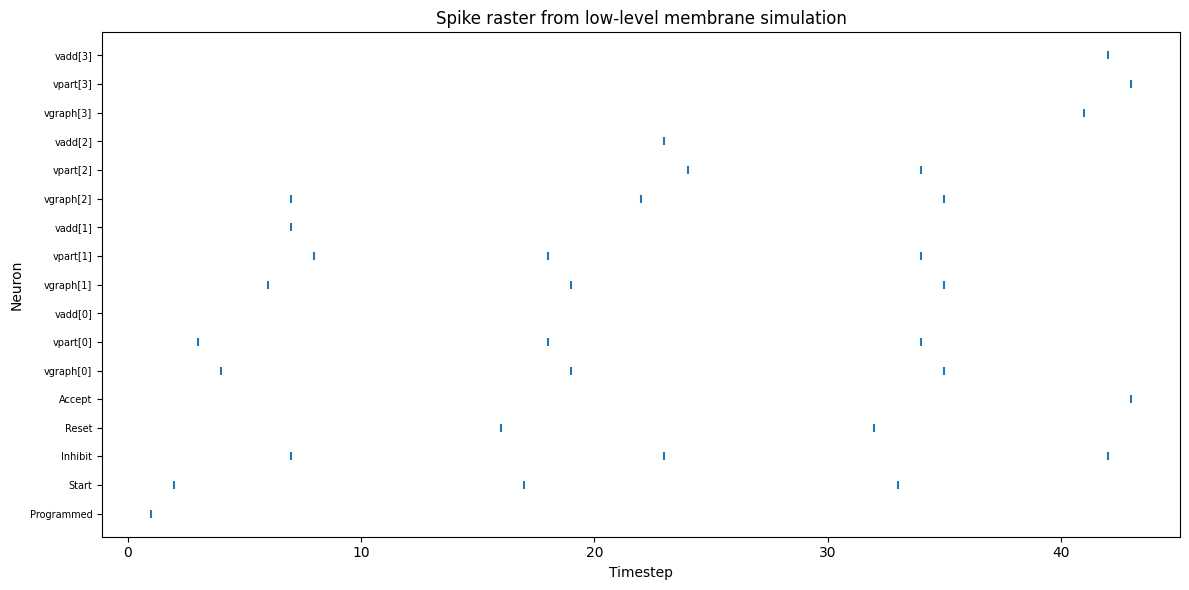

In [10]:
# spike raster
spike_events = result["events"].copy()
spike_events["y"] = pd.Categorical(
    spike_events["neuron"],
    categories=list(neurons.keys()),
    ordered=True,
).codes

plt.figure(figsize=(12, 6))
plt.scatter(spike_events["time"], spike_events["y"], marker="|")
plt.yticks(range(len(neurons)), list(neurons.keys()), fontsize=7)
plt.xlabel("Timestep")
plt.ylabel("Neuron")
plt.title("Spike raster from low-level membrane simulation")
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_spike_raster.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# MST create via spike
def readout_mst_from_spikes(events_df, unique_edges, root):
    """Decode the MST using only Start and vadd spike times."""
    edge_delay = {frozenset((u, v)): int(d) for u, v, d in unique_edges}
    start_times = list(events_df.loc[events_df["neuron"] == "Start", "time"])

    vadd_events = events_df[events_df["neuron"].str.startswith("vadd[")].copy()
    vadd_events["vertex"] = vadd_events["neuron"].str.extract(r"vadd\[(\d+)\]").astype(int)
    vadd_times = list(zip(vadd_events["time"], vadd_events["vertex"]))

    mst_vertices = {root}
    mst_edges = []
    rows = []

    for iteration, (t_add, target) in enumerate(vadd_times, start=1):
        if iteration - 1 >= len(start_times):
            raise RuntimeError("Readout failed: fewer Start spikes than vadd spikes.")

        t_start = start_times[iteration - 1]
        decoded_delay = int(t_add - t_start - 3)

        candidates = []
        for src in mst_vertices:
            key = frozenset((src, target))
            if key in edge_delay and edge_delay[key] == decoded_delay:
                candidates.append(src)

        if len(candidates) != 1:
            raise RuntimeError(
                f"Readout failed for target={target}, delay={decoded_delay}, "
                f"candidates={candidates}, current MST vertices={mst_vertices}"
            )

        src = candidates[0]
        mst_edges.append((min(src, target), max(src, target), decoded_delay))
        mst_vertices.add(target)

        rows.append({
            "iteration": iteration,
            "Start spike t_s": t_start,
            "vadd spike t_add": t_add,
            "added vertex": target,
            "decoded delay d=t_add-t_s-3": decoded_delay,
            "decoded edge": f"{src}-{target}",
        })

    return mst_edges, pd.DataFrame(rows)

snn_mst_edges, readout_table = readout_mst_from_spikes(result["events"], unique_edges, root_vertex)
snn_mst_edges_sorted = sorted(snn_mst_edges)

print("Decoded SNN MST edges:", snn_mst_edges_sorted)
display(readout_table)

Decoded SNN MST edges: [(0, 1, 2), (0, 2, 3), (1, 3, 6)]


,iteration,Start spike t_s,vadd spike t_add,added vertex,decoded delay d=t_add-t_s-3,decoded edge
0,1,2,7,1,2,0-1
1,2,17,23,2,3,0-2
2,3,33,42,3,6,1-3


In [12]:
# validation
G_unique = nx.Graph()
G_unique.add_weighted_edges_from(unique_edges)

nx_mst = nx.minimum_spanning_tree(G_unique, weight="weight")
nx_mst_edges = sorted((min(u, v), max(u, v), int(data["weight"])) for u, v, data in nx_mst.edges(data=True))

print("NetworkX MST:", nx_mst_edges)
print("SNN decoded MST:", snn_mst_edges_sorted)
print("Match:", nx_mst_edges == snn_mst_edges_sorted)

assert nx_mst_edges == snn_mst_edges_sorted

NetworkX MST: [(0, 1, 2), (0, 2, 3), (1, 3, 6)]
SNN decoded MST: [(0, 1, 2), (0, 2, 3), (1, 3, 6)]
Match: True


In [13]:
n = metadata["n"]
max_delay = metadata["max_unique_delay"]

complexity_summary = {
    "|V|": n,
    "|E|": len(unique_edges),
    "max unique delay": max_delay,
    "measured time timesteps until Accept": result["stop_time"],
    "measured space neurons": len(neurons),
    "measured synapses": len(synapses),
    "measured energy total spikes": int(result["events"].shape[0]),
    "improved paper scale |V|*max_delay": n * max_delay,
    "earlier Kay-style scale |V|^2*max_delay": (n ** 2) * max_delay,
    "paper energy scale |V|^2": n ** 2,
}

complexity_df = pd.DataFrame([complexity_summary])
display(complexity_df)

,|V|,|E|,max unique delay,measured time timesteps until Accept,measured space neurons,measured synapses,measured energy total spikes,improved paper scale |V|*max_delay,earlier Kay-style scale |V|^2*max_delay,paper energy scale |V|^2
0,4,5,8,43,17,68,32,32,128,16


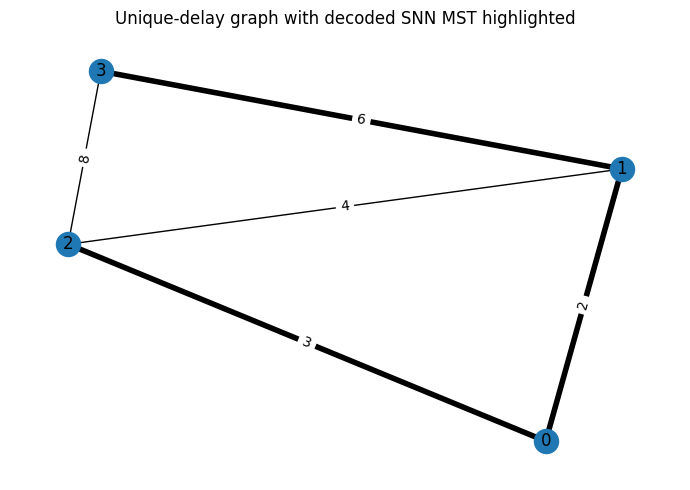

In [14]:

pos = nx.spring_layout(G_unique, seed=GLOBAL_SEED)

plt.figure(figsize=(7, 5))
nx.draw_networkx_nodes(G_unique, pos)
nx.draw_networkx_labels(G_unique, pos)
nx.draw_networkx_edges(G_unique, pos, width=1)

mst_pairs = [(u, v) for u, v, _ in snn_mst_edges_sorted]
nx.draw_networkx_edges(G_unique, pos, edgelist=mst_pairs, width=4)

edge_labels = {(u, v): int(data["weight"]) for u, v, data in G_unique.edges(data=True)}
nx.draw_networkx_edge_labels(G_unique, pos, edge_labels=edge_labels)

plt.title("Unique-delay graph with decoded SNN MST highlighted")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_decoded_mst_graph_new.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
### large scale random test
def random_connected_weighted_graph(n, p, seed, weight_low=1, weight_high=10):
    """Generate a connected Erdos-Renyi graph with random positive integer edge lengths."""
    rng = random.Random(seed)

    while True:
        G = nx.gnp_random_graph(n=n, p=p, seed=rng.randint(0, 10**9))
        if nx.is_connected(G):
            break

    return [(u, v, rng.randint(weight_low, weight_high)) for u, v in G.edges()]


def run_one_low_level_trial(n, p, seed):
    """Run one complete low-level SNN MST trial and validate against NetworkX."""
    edges = random_connected_weighted_graph(n=n, p=p, seed=seed)
    unique_trial, _ = make_unique_integer_lengths(edges)

    neurons_t, synapses_t, initial_t, scheduled_t, meta_t = build_low_level_mst_snn(unique_trial, root=0)
    result_t = simulate_snn(
        neurons=neurons_t,
        synapses=synapses_t,
        initial_u=initial_t,
        scheduled_spikes=scheduled_t,
        max_steps=20000,
        stop_on_accept=True,
    )

    snn_mst_t, _ = readout_mst_from_spikes(result_t["events"], unique_trial, root=0)

    G_t = nx.Graph()
    G_t.add_weighted_edges_from(unique_trial)
    nx_mst_t = sorted(
        (min(u, v), max(u, v), int(data["weight"]))
        for u, v, data in nx.minimum_spanning_tree(G_t, weight="weight").edges(data=True)
    )

    return {
        "n": n,
        "p": p,
        "seed": seed,
        "edges": len(unique_trial),
        "max_delay": meta_t["max_unique_delay"],
        "timesteps": result_t["stop_time"],
        "neurons": len(neurons_t),
        "synapses": len(synapses_t),
        "spikes": int(result_t["events"].shape[0]),
        "match_networkx": sorted(snn_mst_t) == nx_mst_t,
    }

batch_rows = []
for n_trial in [4, 5, 6, 7, 8]:
    for p_trial in [0.45, 0.70, 1.00]:
        for seed_trial in range(5):
            batch_rows.append(run_one_low_level_trial(n_trial, p_trial, seed=1000 * n_trial + 100 * int(p_trial * 100) + seed_trial))

batch_df = pd.DataFrame(batch_rows)

print("Number of trials:", len(batch_df))
print("All trials matched NetworkX:", bool(batch_df["match_networkx"].all()))

display(batch_df)

assert batch_df["match_networkx"].all()

Number of trials: 75
All trials matched NetworkX: True


,n,p,seed,edges,max_delay,timesteps,neurons,synapses,spikes,match_networkx
0,4,0.45,8500,3,5,37,17,64,31,True
1,4,0.45,8501,4,18,83,17,66,31,True
2,4,0.45,8502,3,8,45,17,64,32,True
3,4,0.45,8503,3,9,50,17,64,31,True
4,4,0.45,8504,3,7,47,17,64,31,True
5,4,0.70,11000,5,19,80,17,68,31,True
6,4,0.70,11001,5,9,46,17,68,31,True
7,4,0.70,11002,3,8,51,17,64,31,True
8,4,0.70,11003,6,19,75,17,70,31,True
9,4,0.70,11004,5,17,66,17,68,31,True


,n,p,mean_timesteps,std_timesteps,mean_spikes,std_spikes,mean_edges,mean_max_delay,mean_neurons,mean_synapses
0,4,0.45,52.4,17.770763,31.2,0.447214,3.2,9.4,17.0,64.4
1,4,0.70,63.6,14.774979,31.0,0.000000,4.8,14.4,17.0,67.6
2,4,1.00,89.4,15.709870,31.6,0.547723,6.0,22.6,17.0,70.0
3,5,0.45,99.4,33.155693,45.4,0.894427,5.6,15.0,20.0,82.2
4,5,0.70,112.8,24.933913,45.8,0.836660,7.2,20.4,20.0,85.4
5,5,1.00,183.2,74.734196,45.0,0.000000,10.0,33.8,20.0,91.0
6,6,0.45,158.0,23.334524,61.6,0.894427,7.6,20.6,23.0,99.2
7,6,0.70,172.4,52.983960,62.2,1.095445,11.8,25.4,23.0,107.6
8,6,1.00,231.8,44.684449,61.6,0.894427,15.0,39.4,23.0,114.0
9,7,0.45,227.4,39.947466,79.8,0.447214,11.0,28.4,26.0,119.0


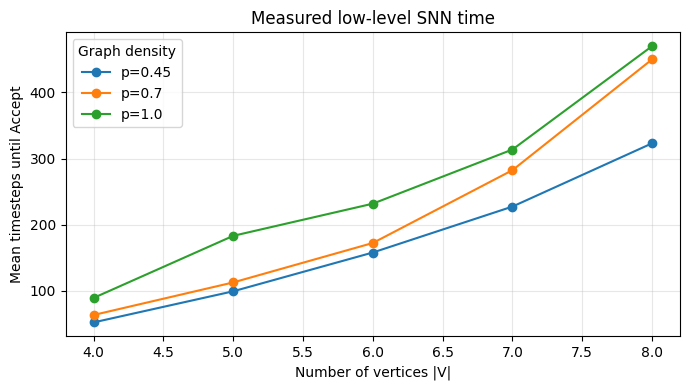

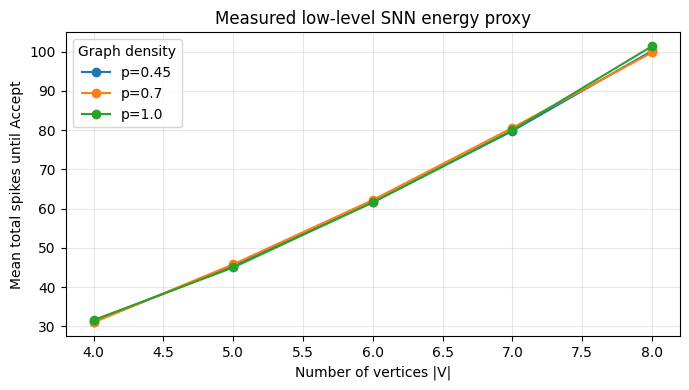

In [16]:
agg_df = (
    batch_df
    .groupby(["n", "p"], as_index=False)
    .agg(
        mean_timesteps=("timesteps", "mean"),
        std_timesteps=("timesteps", "std"),
        mean_spikes=("spikes", "mean"),
        std_spikes=("spikes", "std"),
        mean_edges=("edges", "mean"),
        mean_max_delay=("max_delay", "mean"),
        mean_neurons=("neurons", "mean"),
        mean_synapses=("synapses", "mean"),
    )
)

display(agg_df)

# ------------------------------
# Plot 1: measured low-level time
# ------------------------------
plt.figure(figsize=(7, 4))
for p_value, group in agg_df.groupby("p"):
    group = group.sort_values("n")
    plt.plot(group["n"], group["mean_timesteps"], marker="o", label=f"p={p_value}")

plt.xlabel("Number of vertices |V|")
plt.ylabel("Mean timesteps until Accept")
plt.title("Measured low-level SNN time")
plt.legend(title="Graph density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_measured_time.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------
# Plot 2: measured spike-energy proxy
# ------------------------------------
plt.figure(figsize=(7, 4))
for p_value, group in agg_df.groupby("p"):
    group = group.sort_values("n")
    plt.plot(group["n"], group["mean_spikes"], marker="o", label=f"p={p_value}")

plt.xlabel("Number of vertices |V|")
plt.ylabel("Mean total spikes until Accept")
plt.title("Measured low-level SNN energy proxy")
plt.legend(title="Graph density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_measured_energy_proxy.png", dpi=300, bbox_inches="tight")
plt.show()

agg_df.to_csv(OUT_DIR / "fresh_low_level_time_energy_by_density.csv", index=False)

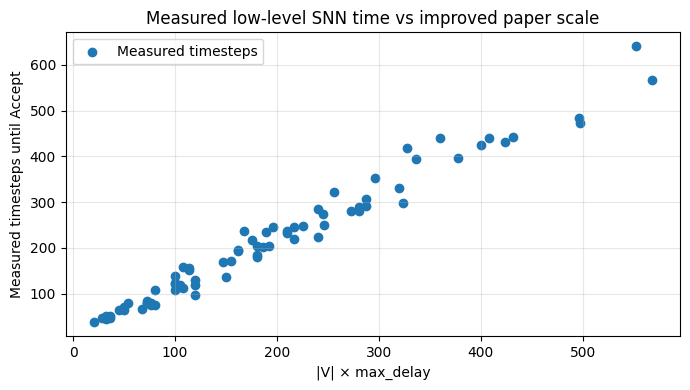

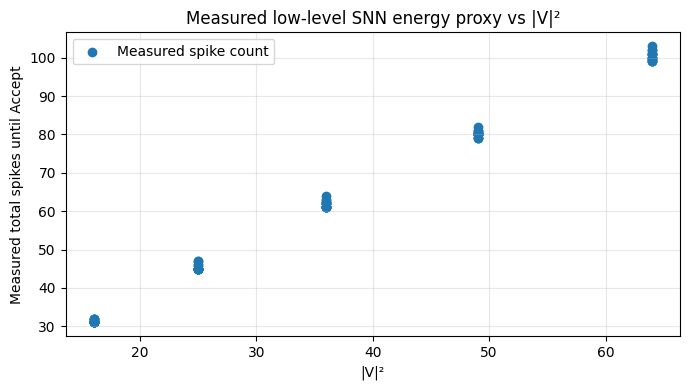

,n,p,seed,edges,max_delay,timesteps,spikes,improved_scale,earlier_scale,energy_scale_v_squared,match_networkx
0,4,0.45,8500,3,5,37,31,20,80,16,True
1,4,0.45,8501,4,18,83,31,72,288,16,True
2,4,0.45,8502,3,8,45,32,32,128,16,True
3,4,0.45,8503,3,9,50,31,36,144,16,True
4,4,0.45,8504,3,7,47,31,28,112,16,True
5,4,0.70,11000,5,19,80,31,76,304,16,True
6,4,0.70,11001,5,9,46,31,36,144,16,True
7,4,0.70,11002,3,8,51,31,32,128,16,True
8,4,0.70,11003,6,19,75,31,76,304,16,True
9,4,0.70,11004,5,17,66,31,68,272,16,True


In [17]:
plot_df = batch_df.copy()
plot_df["improved_scale"] = plot_df["n"] * plot_df["max_delay"]
plot_df["earlier_scale"] = (plot_df["n"] ** 2) * plot_df["max_delay"]
plot_df["energy_scale_v_squared"] = plot_df["n"] ** 2

plt.figure(figsize=(7, 4))
plt.scatter(plot_df["improved_scale"], plot_df["timesteps"], label="Measured timesteps")
plt.xlabel("|V| × max_delay")
plt.ylabel("Measured timesteps until Accept")
plt.title("Measured low-level SNN time vs improved paper scale")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_time_vs_improved_scale.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(plot_df["energy_scale_v_squared"], plot_df["spikes"], label="Measured spike count")
plt.xlabel("|V|²")
plt.ylabel("Measured total spikes until Accept")
plt.title("Measured low-level SNN energy proxy vs |V|²")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fresh_low_level_energy_vs_v_squared.png", dpi=300, bbox_inches="tight")
plt.show()

# Save the trial-level dataframe with explicit scale columns.
plot_df.to_csv(OUT_DIR / "fresh_low_level_batch_tests_with_scales.csv", index=False)

display(plot_df[[
    "n", "p", "seed", "edges", "max_delay",
    "timesteps", "spikes", "improved_scale", "earlier_scale", "energy_scale_v_squared",
    "match_networkx",
]])